In [2]:
from langgraph.graph import StateGraph, START , END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
model = ChatOpenAI()

In [4]:
# Create a State

class QNAState(TypedDict):

    question: str
    answer: str 

In [5]:
def llm_qna(state: QNAState) -> QNAState:

    # Extract the question from the prompt

    question = state['question']

    # Create a prompt

    prompt = f"Answer the following question. {question}"

    # Ask the question to llm

    answer = model.invoke(prompt).content

    # Update the answer in the state

    state['answer'] = answer

    return state

In [6]:
# Create a Graph

graph = StateGraph(QNAState)

# Add nodes

graph.add_node("llm_qna",llm_qna)

# Create edges

graph.add_edge(START, 'llm_qna')
graph.add_edge('llm_qna',END)

# Complile

workflow = graph.compile()


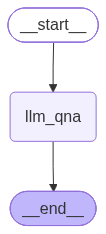

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [7]:
# Execute

initial_state = {'question':'What is the radius of Earth?'}

final_state = workflow.invoke(initial_state)

print(final_state['answer'])

The radius of the Earth is approximately 6,371 kilometers (3,959 miles).
